In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import os
from scipy.signal import savgol_filter



2025-09-20 04:49:05.652987: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-20 04:49:05.708150: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-20 04:49:06.604475: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def c6_data():
    df = pd.read_csv('Fill-1.csv')
    print(df.shape)

    # 删除重复值
    df.drop_duplicates(inplace=True)
    print(df.shape)

    x = df.iloc[:, :2].values
    y = df.iloc[:, 2].values

    print(x.shape, y.shape)
    
    # 归一化
    scaler_x = StandardScaler()
    scaler_x.fit(x)
    x = scaler_x.transform(x)

    scaler_y = StandardScaler()
    y = y.reshape(-1, 1)  # Reshape y to have one feature
    scaler_y.fit(y)
    y = scaler_y.transform(y)

    # 划分数据集
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=666)

    return x_train, x_test, y_train, y_test, scaler_x, scaler_y

# 保存处理后的数据在csv文件里
x_train, x_test, y_train, y_test, scaler_x, scaler_y = c6_data()

x_train_reshaped = x_train.reshape(x_train.shape[0], x_train.shape[1])
x_test_reshaped = x_test.reshape(x_test.shape[0], x_test.shape[1])

y_train_reshaped = y_train.reshape(y_train.shape[0], y_train.shape[1])
y_test_reshaped = y_test.reshape(y_test.shape[0], y_test.shape[1])

# 将数据转换为DataFrame
df_x_train = pd.DataFrame(x_train_reshaped)
df_x_test = pd.DataFrame(x_test_reshaped)
df_y_train = pd.DataFrame(y_train_reshaped)
df_y_test = pd.DataFrame(y_test_reshaped)

# 保存到CSV文件
df_x_train.to_csv('x_train_tl.csv', index=False)
df_x_test.to_csv('x_test_tl.csv', index=False)
df_y_train.to_csv('y_train_tl.csv', index=False)
df_y_test.to_csv('y_test_tl.csv', index=False)


(169544, 3)
(135550, 3)
(135550, 2) (135550,)


In [3]:
# Define the ANN model
model_ann = Sequential()
model_ann.add(Dense(30, activation='relu', input_dim=x_train.shape[1]))
model_ann.add(Dense(30, activation='relu'))
model_ann.add(Dense(1))
model_ann.compile(optimizer='adam', loss='mse')


2025-09-20 04:49:13.445302: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9613 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:b4:00.0, compute capability: 7.5


In [4]:
model_ann.load_weights('./annmodel/model_ann_weight')


In [5]:
# 解冻更多层
for layer in model_ann.layers[:1]:  # 
    layer.trainable = False
    print(f"Layer {layer.name} is frozen.")
# 添加更多层
model_ann.add(Dense(50, activation='relu'))
model_ann.add(Dense(1))


Layer dense is frozen.


In [6]:
# Compile the model with a lower learning rate
model_ann.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])


In [7]:
# Fine-tune the model with new data
history = model_ann.fit(x_train, y_train, epochs=50, batch_size=200, validation_data=(x_test, y_test))


Epoch 1/50


2024-10-29 05:38:51.035399: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5590ba254400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-29 05:38:51.035421: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2024-10-29 05:38:51.039910: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-29 05:38:51.055524: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2024-10-29 05:38:51.181743: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


543/543 [==============================] - 3s 2ms/step - loss: 0.6482 - mae: 0.7042 - val_loss: 0.3070 - val_mae: 0.4308
Epoch 2/50
543/543 [==============================] - 1s 2ms/step - loss: 0.2541 - mae: 0.3815 - val_loss: 0.2269 - val_mae: 0.3533
Epoch 3/50
543/543 [==============================] - 1s 2ms/step - loss: 0.2060 - mae: 0.3349 - val_loss: 0.1886 - val_mae: 0.3205
Epoch 4/50
543/543 [==============================] - 1s 2ms/step - loss: 0.1697 - mae: 0.3058 - val_loss: 0.1565 - val_mae: 0.2939
Epoch 5/50
543/543 [==============================] - 1s 2ms/step - loss: 0.1427 - mae: 0.2816 - val_loss: 0.1342 - val_mae: 0.2736
Epoch 6/50
543/543 [==============================] - 1s 2ms/step - loss: 0.1217 - mae: 0.2614 - val_loss: 0.1150 - val_mae: 0.2540
Epoch 7/50
543/543 [==============================] - 1s 2ms/step - loss: 0.1046 - mae: 0.2422 - val_loss: 0.1000 - val_mae: 0.2347
Epoch 8/50
543/543 [==============================] - 1s 2ms/step - loss: 0.0911 - mae:

In [7]:
model_ann.load_weights('./anntlmodel/model_ann_weight_TL')
print("Fine-tuned model loaded from disk.")


Fine-tuned model loaded from disk.


In [8]:
# Predict using ANN model
y_pred_ann = model_ann.predict(x_test)

# Calculate Mean Squared Error (MSE)
mse_ann = mean_squared_error(y_test, y_pred_ann)

# Calculate Root Mean Squared Error (RMSE)
rmse_ann = np.sqrt(mse_ann)

# Calculate Mean Absolute Error (MAE)
mae_ann = mean_absolute_error(y_test, y_pred_ann)

# Calculate R² Score
r2_ann = r2_score(y_test, y_pred_ann)

print(f"Mean Squared Error (MSE): {mse_ann}")
print(f"Root Mean Squared Error (RMSE): {rmse_ann}")
print(f"Mean Absolute Error (MAE): {mae_ann}")
print(f"R² Score: {r2_ann}")


848/848 [==============================] - 1s 877us/step
Mean Squared Error (MSE): 0.042916870745473026
Root Mean Squared Error (RMSE): 0.2071638741322266
Mean Absolute Error (MAE): 0.1049760951195578
R² Score: 0.9575397107065281


In [9]:
model_ann.save('anntlmodel.h5')

/root/miniconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
# Save the fine-tuned model
model_ann.save_weights('./anntlmodel/model_ann_weight_TL')
print("Fine-tuned model saved to disk.")


Fine-tuned model saved to disk.


损失图已保存到: tl_ann_fig/loss_plot.png
局部放大损失图已保存到: tl_ann_fig/zoom_loss_plot.png


/tmp/ipykernel_24620/1296409774.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


结合图已保存到: tl_ann_fig/combined_plot_zoomed.png


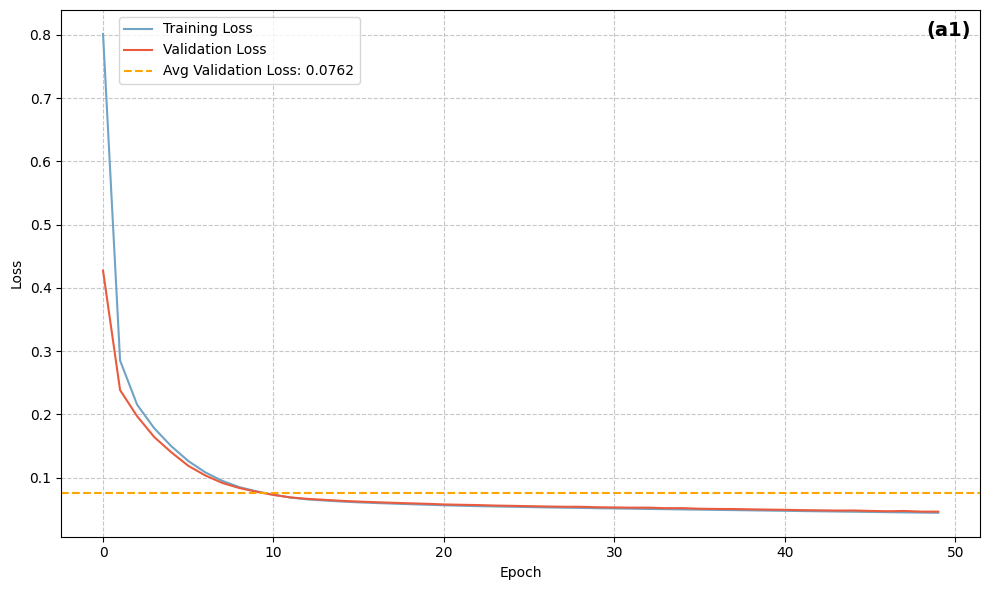

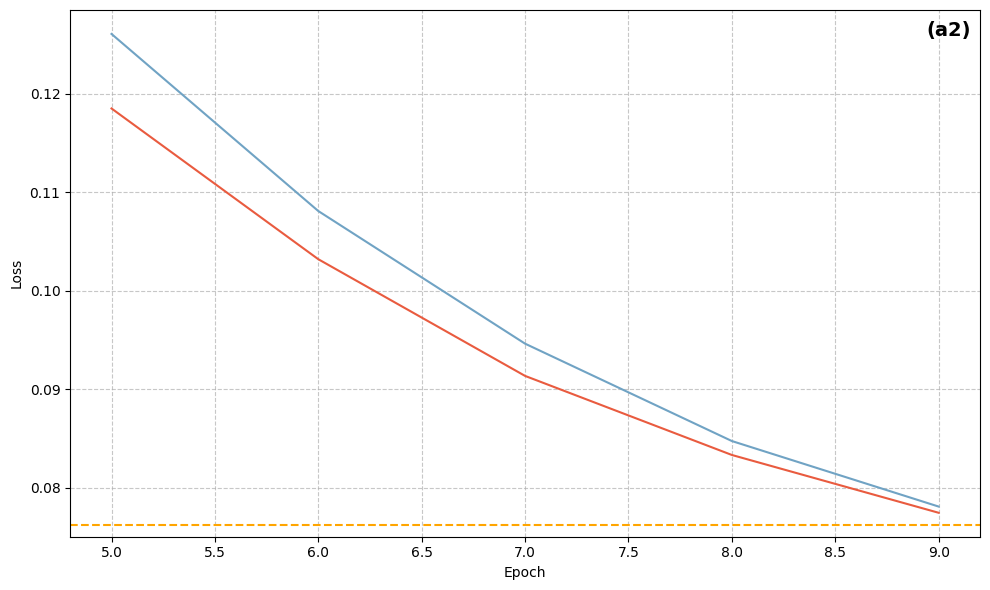

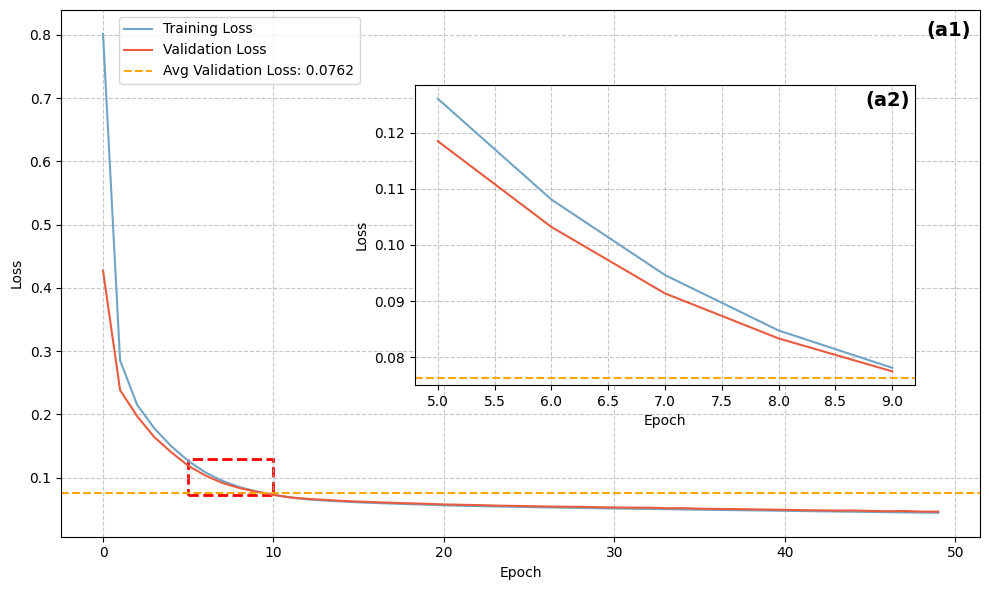

In [52]:
# 创建保存图片的文件夹
folder_name = "tl_ann_fig"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 自定义放大区间
zoom_epoch_start = 5  # 自定义起始 epoch
zoom_epoch_end = 10   # 自定义结束 epoch

# 自定义虚线框高度和宽度
rect_y_min = 0.073  # 自定义虚线框的下边界
rect_y_max = 0.13  # 自定义虚线框的上边界
rect_x_start = 5    # 自定义虚线框的左边界
rect_x_end = 10     # 自定义虚线框的右边界

    
# 绘制训练和验证损失图
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(history.history['loss'], color='#70A3C4', label='Training Loss')
ax1.plot(history.history['val_loss'], color='#E95B3F', label='Validation Loss')
avg_val_loss = np.mean(history.history['val_loss'])
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(a1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
loss_file_path = os.path.join(folder_name, 'loss_plot.png')
plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
print(f"损失图已保存到: {loss_file_path}")

# 绘制局部放大图
fig, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(range(zoom_epoch_start, zoom_epoch_end), history.history['loss'][zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), history.history['val_loss'][zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.text(0.99, 0.98, '(a2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# 绘制结合图，将局部放大图嵌入到主图中
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(history.history['loss'], color='#70A3C4', label='Training Loss')
ax1.plot(history.history['val_loss'], color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(a1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 嵌入放大损失图
inset_ax = fig.add_axes([0.42, 0.35, 0.5, 0.5])  # [left, bottom, width, height]
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), history.history['loss'][zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), history.history['val_loss'][zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')  # 添加平均值线
inset_ax.set_xlabel('Epoch')
inset_ax.set_ylabel('Loss')
inset_ax.grid(True, linestyle='--', alpha=0.7)
inset_ax.text(0.99, 0.98, '(a2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 添加红色虚线框
rect = plt.Rectangle((rect_x_start, rect_y_min), 
                     rect_x_end - rect_x_start, 
                     rect_y_max - rect_y_min, 
                     edgecolor='red', linestyle='--', linewidth=2, facecolor='none', transform=ax1.transData)
ax1.add_patch(rect)

# 添加标注和链接
# ax1.annotate('', xy=(0.6, 0.45), xycoords='axes fraction', xytext=(0.45, 0.25), textcoords='axes fraction',
#              arrowprops=dict(facecolor='black', shrink=0.05, width=2))

plt.tight_layout()
combined_file_path = os.path.join(folder_name, 'combined_plot_zoomed.png')
plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
print(f"结合图已保存到: {combined_file_path}")

# 显示图表
plt.show()

Fine-tuned model loaded from disk.
825/825 [==============================] - 1s 854us/step


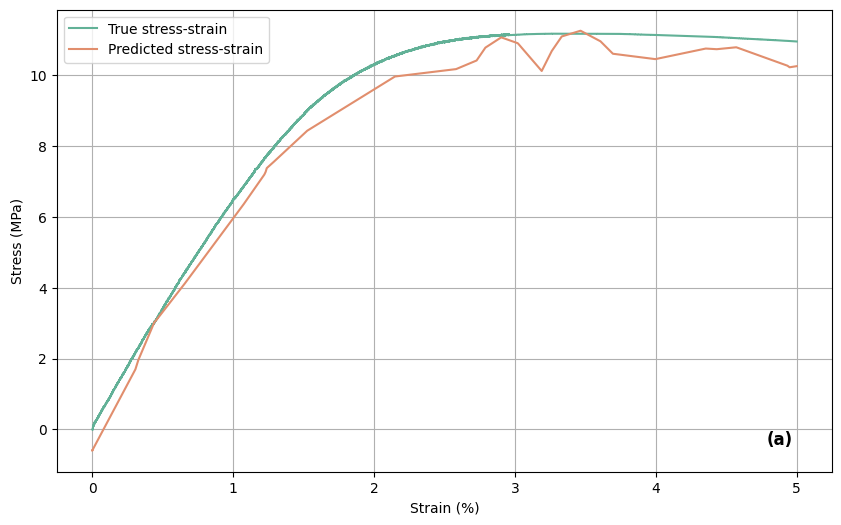

应力-应变曲线已保存并显示: tl_ann_fig/prediction/stress_strain_curve_fill_7.png


In [26]:

# 确保保存图片的文件夹存在
folder_path = os.path.join('tl_ann_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    
# 加载迁移学习后的模型权重
model_ann.load_weights('./anntlmodel/model_ann_weight_TL')
print("Fine-tuned model loaded from disk.")

# 读取新数据
file_name = '60-p.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 进行预测
stress_pred_scaled = model_ann.predict(x_new_scaled)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(stress_pred_scaled.reshape(-1, 1)).flatten()


# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 使用特定的应变阈值
strain_threshold = 5  # 根据之前的阈值设置
valid_indices = strain_truncated < strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]

# 对预测值进行平滑处理
stress_pred_smoothed = savgol_filter(stress_pred_truncated, window_length=331, polyorder=1)


# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated, label='True stress-strain', color='#62B197')
plt.plot(strain_truncated, stress_pred_truncated, label='Predicted stress-strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')
plt.legend()
# plt.title('True vs Predicted Stress-Strain Curve')
plt.grid(True)

# 在右下角添加文本 (b1)
plt.text(0.95, 0.05, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')

# 保存图像
save_path = os.path.join(folder_path, 'stress_strain_curve_fill_7.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")

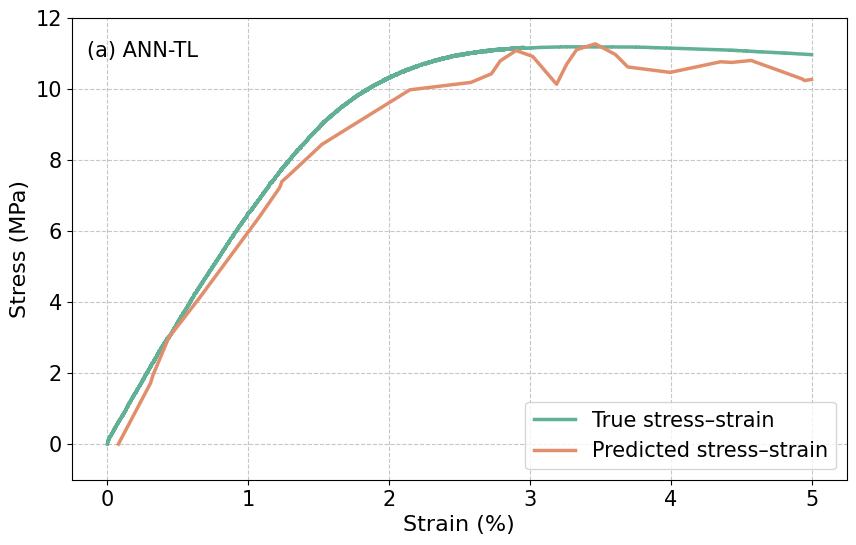

应力-应变曲线已保存并显示: tl_ann_fig/prediction/predicted_vs_true_curve.png


In [27]:
# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 使用特定的应变阈值（与 LSTM 图一致：≤ 5）
strain_threshold = 5
valid_indices = strain_truncated <= strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]

# 仅隐藏预测值 < 0 的部分（不动真值与横轴）
stress_pred_display = stress_pred_truncated.copy()
stress_pred_display[stress_pred_display < 0] = np.nan

# —— 绘图（保持和 LSTM 图一致的样式） ——
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated,
         label='True stress–strain', color='#62B197', linewidth=2.5)
plt.plot(strain_truncated, stress_pred_display,
         label='Predicted stress–strain', color='#E18E6D', linewidth=2.5)

plt.ylim(-1, 12)
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 左上角角标（统一风格）
plt.text(0.02, 0.95, '(a) ANN-TL', transform=plt.gca().transAxes,
         fontsize=15, ha='left', va='top')

# 保存路径
folder_path = os.path.join('tl_ann_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)
save_path = os.path.join(folder_path, 'predicted_vs_true_curve.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")


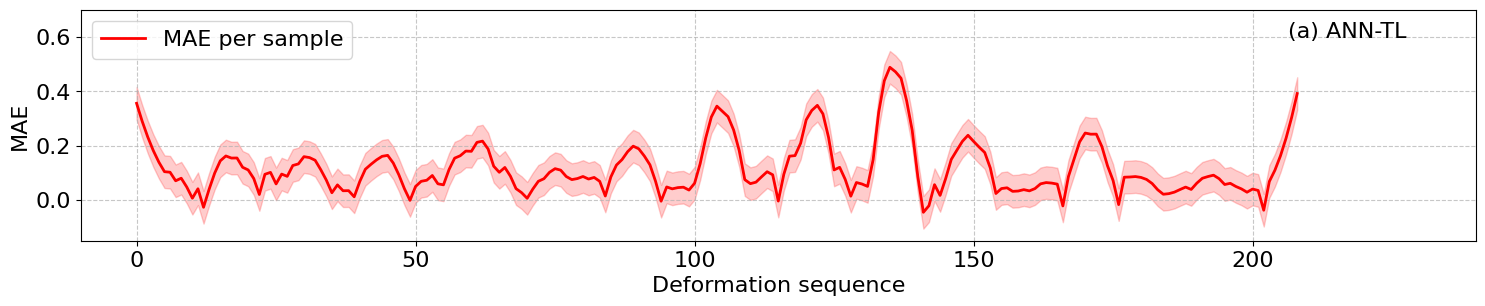

MAE per sample plot saved and displayed: ./tl_ann_fig/mae_per_sample.png


In [22]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator

# 计算每个样本的 MAE
mae_per_sample = np.abs(y_test - y_pred_ann).flatten()

# 采样数据以减少密度（例如，每隔250个点取一个）
sampling_rate = 130
mae_sampled = mae_per_sample[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)

# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per sample', color='red', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.06  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='red', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=16)

# 在右上角添加文本 (a)
plt.text(0.95, 0.95, '(a) ANN-TL', fontsize=16, ha='right', va='top', transform=plt.gca().transAxes)

plt.xlabel('Deformation sequence', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.15, 0.7)
plt.xlim(-10, 240)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# 保存图像
mae_timestep_path = './tl_ann_fig/mae_per_sample.png'
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per sample plot saved and displayed: {mae_timestep_path}")

正在从以下路径加载权重: anntlmodel/model_ann_weight_TL
权重加载成功！
复用训练阶段的 Scaler（来自 TL 过程）。
正在加载并处理评估数据: Fill-1.csv
评估数据处理完成。
正在进行预测...
4236/4236 [==============================] - 3s 800us/step
预测与误差计算完成。
正在准备绘图数据（分步式插值）...
绘图数据准备完成。
正在绘制图形（LogNorm）...
[ANN-TL] 建议范围 => vmin=3.85907e-05, vmax=17.5884
误差等高线图已保存为: tl_ann_fig/anntl_error_contour_log_scale_formatted.png


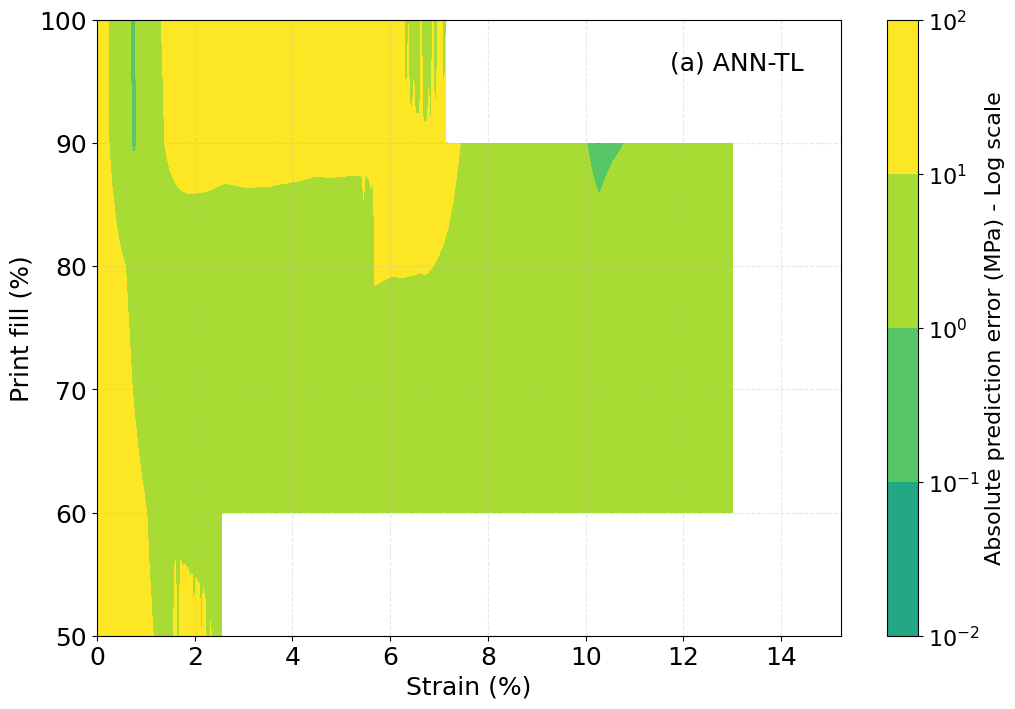

In [14]:
GLOBAL_VMIN = 1.13126e-06
GLOBAL_VMAX = 28.4838

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scipy.interpolate import interp1d
import matplotlib.colors as colors
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler  # 新增导入

# --- 配置参数 ---
WEIGHTS_PATH = 'anntlmodel/model_ann_weight_TL'
# 数据文件路径（迁移学习统一使用 Fill-1）
ORIGINAL_DATA_PATH = 'Fill-1.csv'  # 用于训练 Scaler 的数据（迁移学习数据）
EVALUATION_DATA_PATH = 'Fill-1.csv'  # 用于评估和绘图的迁移学习数据

# --- 1. 重新定义模型结构 ---
# 与保存权重时一致
def create_my_model():
    model = Sequential([
        Dense(30, activation='relu', input_shape=(2,)),
        Dense(30, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# --- 主程序 ---

# 创建与保存权重时相同的模型实例
model = create_my_model()

# 加载权重到模型结构中
print(f"正在从以下路径加载权重: {WEIGHTS_PATH}")
model.load_weights(WEIGHTS_PATH)
print("权重加载成功！")

# --- 2. 使用与训练一致的 Scaler（优先复用，若无则按 TL 数据重建） ---
try:
    _ = scaler_x.mean_
    _ = scaler_y.mean_
    print("复用训练阶段的 Scaler（来自 TL 过程）。")
except Exception:
    print(f"未检测到已有 Scaler，基于 {ORIGINAL_DATA_PATH} 重建（与 TL 一致）...")
    df_original = pd.read_csv(ORIGINAL_DATA_PATH)
    df_original.drop_duplicates(inplace=True)
    x_original = df_original.iloc[:, :2].values
    y_original = df_original.iloc[:, 2].values.reshape(-1, 1)
    scaler_x = StandardScaler().fit(x_original)
    scaler_y = StandardScaler().fit(y_original)
    print("Scaler 重建完成。")

# --- 3. 加载并处理用于评估的数据 ---
print(f"正在加载并处理评估数据: {EVALUATION_DATA_PATH}")
df_eval = pd.read_csv(EVALUATION_DATA_PATH)
df_eval.drop_duplicates(inplace=True)

x_eval = df_eval.iloc[:, :2].values
y_eval = df_eval.iloc[:, 2].values.reshape(-1, 1)

x_eval_scaled = scaler_x.transform(x_eval)
print("评估数据处理完成。")

# --- 4. 预测并计算绝对误差 ---
print("正在进行预测...")
y_pred_scaled = model.predict(x_eval_scaled)
stress_pred = scaler_y.inverse_transform(y_pred_scaled)
absolute_error = np.abs(stress_pred - y_eval).flatten()
print("预测与误差计算完成。")

# --- 5. 分步式插值构建规则网格（沿应变→沿角度，线性插值） ---
print("正在准备绘图数据（分步式插值）...")
# 原始变量（假定第0列为角度，第1列为应变）
angle_original = x_eval[:, 0]
strain_original = x_eval[:, 1]

# 组装绘图DataFrame
df_plot = pd.DataFrame({
    'Strain': strain_original.astype(float),
    'Angle': angle_original.astype(float),
    'Error': absolute_error.astype(float)
})
# 导出误差点表 CSV
out_dir = os.path.join('error_points')
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'ann_tl_points.csv'), index=False)


# 按角度取整分组
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].dropna().unique())

# 统一的应变和角度网格
grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

# 第一步：每个角度组内，沿应变插值到 strain_common
aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f_strain = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f_strain(strain_common)

# 第二步：对每个应变点，沿角度插值到 angle_grid_dense
final_grid_error = np.full((len(angle_grid_dense), len(strain_common)), np.nan)
for i in range(len(strain_common)):
    current_errors = []
    valid_angles = []
    for ang in unique_angles:
        if ang in aligned_errors:
            current_errors.append(aligned_errors[ang][i])
            valid_angles.append(ang)
    if len(valid_angles) > 1:
        current_errors = np.array(current_errors, dtype=float)
        valid_angles = np.array(valid_angles, dtype=float)
        mask = ~np.isnan(current_errors)
        if np.sum(mask) > 1:
            f_angle = interp1d(valid_angles[mask], current_errors[mask], bounds_error=False, fill_value=np.nan)
            final_grid_error[:, i] = f_angle(angle_grid_dense)

print("绘图数据准备完成。")

# --- 6. 绘制（LogNorm，对数色阶；屏蔽 NaN 和 ≤0） ---
print("正在绘制图形（LogNorm）...")
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

# 构造网格（与你给定方法一致）
target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
plt.style.use('default')

# 动态 LogNorm：最小正误差到最大误差（与你给定方法一致）
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
final_grid_error_masked = np.ma.masked_less_equal(final_grid_error, 0)  # 遮罩 ≤0
norm = mcolors.LogNorm(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)              # 统一色条
contour = ax.contourf(target_strain, target_angle, final_grid_error_masked,
                      levels=100, cmap='viridis', norm=norm)
print(f"[ANN-TL] 建议范围 => vmin={min_error_for_log:.6g}, vmax={df_plot['Error'].max():.6g}")
# 连续 100 层等高线填色（与你给定方法一致）


# 颜色条与字体
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16)
cbar.ax.tick_params(labelsize=16)

# 轴与网格
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print fill (%)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18)

# 角标
ax.text(0.95, 0.95, '(a) ANN-TL', transform=ax.transAxes, fontsize=18, ha='right', va='top')

# 保存
output_filename = os.path.join('tl_ann_fig', 'anntl_error_contour_log_scale_formatted.png')
os.makedirs(os.path.dirname(output_filename), exist_ok=True)
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"误差等高线图已保存为: {output_filename}")
plt.show()

In [9]:
# 计算 60-p.csv 的 MAE / RMSE / R²（全量与 Strain≤5）并保存
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 目录确保
out_dir = os.path.join('tl_ann_fig', 'prediction')
os.makedirs(out_dir, exist_ok=True)

# 确保加载迁移学习后的权重（若当前会话未加载）
try:
    _ = model_ann  # 存在则复用
except NameError:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense
    model_ann = Sequential([
        Dense(30, activation='relu', input_shape=(2,)),
        Dense(30, activation='relu'),
        Dense(1)
    ])
    model_ann.compile(optimizer='adam', loss='mse')

# 加载 TL 权重（幂等）
model_ann.load_weights('./anntlmodel/model_ann_weight_TL')

# 读取未见测试集（60-p.csv）
df_test = pd.read_csv('60-p.csv')
# 特征与目标：列顺序 [Angle, Strain, Stress]
x_new = df_test.iloc[:, :2].values
strain = df_test.iloc[:, 1].values  # 第二列应变
stress_true = df_test.iloc[:, 2].values.reshape(-1, 1)

# 使用迁移学习阶段的 scaler 做归一化与反归一化
x_new_scaled = scaler_x.transform(x_new)
# 预测（不做平滑，直接评估原始预测性能）
y_pred_scaled = model_ann.predict(x_new_scaled)
stress_pred = scaler_y.inverse_transform(y_pred_scaled)

# 扁平化
true_all = stress_true.flatten()
pred_all = stress_pred.flatten()
strain_all = strain

# 全量指标
mse_all = mean_squared_error(true_all, pred_all)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(true_all, pred_all)
r2_all = r2_score(true_all, pred_all)

# 阈值（与图一致）：Strain ≤ 5
mask = strain_all <= 5
true_thr = true_all[mask]
pred_thr = pred_all[mask]

mse_thr = mean_squared_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
rmse_thr = np.sqrt(mse_thr) if np.isfinite(mse_thr) else np.nan
mae_thr = mean_absolute_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
r2_thr = r2_score(true_thr, pred_thr) if len(true_thr) > 1 else np.nan

# 打印结果
print('=== 60-p.csv metrics (ANN-TL) ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
if np.isfinite(mae_thr):
    print(f'Strain≤5     -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')
else:
    print('Strain≤5     -> 无有效样本')

# 保存 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<=5',  'MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join(out_dir, '60-p_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')


825/825 [==============================] - 1s 955us/step
=== 60-p.csv metrics (ANN-TL) ===
All samples   -> MAE=0.4794, RMSE=0.6633, R²=0.9327
Strain≤5     -> MAE=0.4932, RMSE=0.5375, R²=0.9729
Metrics saved to: tl_ann_fig/prediction/60-p_metrics.csv
